Bloc 8.0 — Setup, chemins, filtre figé, dérivations, intégrité

In [1]:
# ════════════════════════════════════════════════════════════════════════════
# NOTEBOOK 08a — M2 STATISTIQUE GLOBAL, DÉTECTEUR COMBINÉ (PTB-XL + Ningbo)
# Représentation 100% sans détection d'événement : stats / spectre / autocorr.
# Juge : AP. Primaire : AUC. Fold 10 VIERGE.
# ════════════════════════════════════════════════════════════════════════════
# Bloc 8.0 — Setup, chemins, filtre figé, dérivations, intégrité.  PERMANENT
import os, sys, json
import numpy as np
import pandas as pd

ROOT      = r'C:\Users\natha\Documents\ML_WPW\wpw_project_v2'
PROCESSED = os.path.join(ROOT, 'data', 'processed')
MODELS    = os.path.join(ROOT, 'models', 'M2_statistical')
SRC       = os.path.join(ROOT, 'src')
os.makedirs(MODELS, exist_ok=True)
os.makedirs(os.path.join(ROOT, 'reports', 'figures'), exist_ok=True)
sys.path.insert(0, SRC)

# Chargeur canonique (source de vérité unique du chargement signal)
from signal_loading import load_signal, LEADS_CANONICAL
print("signal_loading OK — ordre canonique :", LEADS_CANONICAL)

# Filtre FIGÉ (gravé en 06e) — lu, jamais redécidé
with open(os.path.join(PROCESSED, 'filter_config.json'), encoding='utf-8') as f:
    FCFG = json.load(f)['filter_FINAL']
assert (FCFG['low'], FCFG['high'], FCFG['order']) == (0.5, 40, 4), "Filtre inattendu !"
FS = FCFG['fs']
print(f"Filtre figé : {FCFG['type']} ordre {FCFG['order']}, {FCFG['low']}-{FCFG['high']} Hz, {FCFG['phase']}")

# M2 = LARGE : les 12 dérivations. Le gate FDR tranchera.
LEADS_M2 = list(LEADS_CANONICAL)  # 12 dérivations
LEAD_IDX = {L: LEADS_CANONICAL.index(L) for L in LEADS_M2}
print(f"Dérivations M2 : {len(LEADS_M2)} (les 12) -> {LEADS_M2}")

# Fichier de features (produit en 8.1 — n'existe pas encore)
FEATURES_CSV = os.path.join(PROCESSED, 'm2_features.csv')

# Métadonnées combinées
meta = pd.read_csv(os.path.join(PROCESSED, 'metadata_combined.csv'), dtype={'ecg_id': str})
n_wpw = int((meta.label == 1).sum())
print(f"\nmetadata_combined : {len(meta)} ECG, {n_wpw} WPW")
print(f"WPW par fold : {meta[meta.label==1].groupby('fold').size().to_dict()}")
print(f"Train(1-8): {int(meta[(meta.fold.between(1,8))&(meta.label==1)].shape[0])} | "
      f"Val(9): {int(meta[(meta.fold==9)&(meta.label==1)].shape[0])} | "
      f"Test(10): {int(meta[(meta.fold==10)&(meta.label==1)].shape[0])} [VIERGE]")
assert n_wpw == 142, "Attendu 142 WPW dans le combiné !"
print("\nBloc 8.0 OK — contexte chargé, filtre vérifié. Prêt pour 8.1 (extraction massive M2).")

signal_loading OK — ordre canonique : ['I', 'II', 'III', 'AVR', 'AVL', 'AVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
Filtre figé : butterworth ordre 4, 0.5-40 Hz, zero-phase (sosfiltfilt)
Dérivations M2 : 12 (les 12) -> ['I', 'II', 'III', 'AVR', 'AVL', 'AVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']

metadata_combined : 66951 ECG, 142 WPW
WPW par fold : {1: 16, 2: 16, 3: 15, 4: 11, 5: 14, 6: 14, 7: 15, 8: 14, 9: 13, 10: 14}
Train(1-8): 115 | Val(9): 13 | Test(10): 14 [VIERGE]

Bloc 8.0 OK — contexte chargé, filtre vérifié. Prêt pour 8.1 (extraction massive M2).


8.1 — Extraction M2 statistique MASSIVE (100% sans détection d'événement)

In [8]:
# Bloc 8.1 — Extraction M2 statistique MASSIVE (100% sans détection d'événement).  PERMANENT
# Familles : stats temporelles (+ ordre supérieur, Teager-Kaiser, franchissements),
#            Hjorth (+ dérivées 2/3, |signal|), spectral (bandes + peigne fin 2.5Hz,
#            roll-off, flux), autocorrélation (rythme + lags + harmoniques),
#            non-linéaire (asymétrie temporelle), permutation entropy multi-échelle.
#            ~120-130 feat/lead × 12 ≈ 1450-1550 features.
# Étapes : test synthétique -> chrono 200 ECG (ETA) -> run complet (RUN_FULL=True).
# Garde-fou anti-relance. Parallèle 10 cœurs + tqdm.

FORCE_REEXTRACT = False     # True pour régénérer même si le CSV existe
RUN_FULL        = True     # passe à True APRÈS avoir vu l'ETA du chrono 200

import warnings, time, contextlib, math
import numpy as np
from scipy.signal import butter, sosfiltfilt, welch
from scipy.stats import skew, kurtosis, iqr
from joblib import Parallel, delayed
from tqdm import tqdm
warnings.filterwarnings('ignore')

# ── Filtre passe-bande figé (identique à l'entraînement et à Flask) ──────────
SOS_BP = butter(FCFG['order'], [FCFG['low']/(FS/2), FCFG['high']/(FS/2)], btype='band', output='sos')
def bp(x): return sosfiltfilt(SOS_BP, np.asarray(x, dtype=np.float64))

# ── tqdm pour joblib ─────────────────────────────────────────────────────────
@contextlib.contextmanager
def tqdm_joblib(t):
    import joblib
    class _Cb(joblib.parallel.BatchCompletionCallBack):
        def __call__(self, *a, **k): t.update(n=self.batch_size); return super().__call__(*a, **k)
    old = joblib.parallel.BatchCompletionCallBack
    joblib.parallel.BatchCompletionCallBack = _Cb
    try: yield t
    finally: joblib.parallel.BatchCompletionCallBack = old; t.close()

# ── Bandes spectrales (Hz). 15-40 = bande delta-sensible (cf. §8.2). ──────────
BANDS = {
    'tot': (0.5, 40), 'vlf': (0.5, 3), 'lf': (3, 8), 'mf': (8, 15),
    'delta_hf': (15, 25), 'hf': (25, 40), 'd1540': (15, 40),
}

# ═══════════════════════════════════════════════════════════════════════════
# FAMILLES DE FEATURES (toutes 100% sans détection de pic)
# ═══════════════════════════════════════════════════════════════════════════
def f_temporal(x):
    """Statistiques de la distribution d'amplitude (sans notion de battement)."""
    o = {}
    o['mean']   = float(np.mean(x));      o['std']  = float(np.std(x))
    o['var']    = float(np.var(x));       o['rms']  = float(np.sqrt(np.mean(x**2)))
    o['mad']    = float(np.median(np.abs(x - np.median(x))))
    o['iqr']    = float(iqr(x));          o['rng']  = float(np.ptp(x))
    o['min']    = float(np.min(x));       o['max']  = float(np.max(x))
    o['p05']    = float(np.percentile(x, 5));  o['p25'] = float(np.percentile(x, 25))
    o['p75']    = float(np.percentile(x, 75)); o['p95'] = float(np.percentile(x, 95))
    o['skew']   = float(skew(x));         o['kurt'] = float(kurtosis(x))
    o['absmean']= float(np.mean(np.abs(x)))
    o['absmax'] = float(np.max(np.abs(x)))
    o['crest']  = float(np.max(np.abs(x)) / (o['rms'] + 1e-9))
    o['shape']  = float(o['rms'] / (o['absmean'] + 1e-9))
    o['impulse']= float(np.max(np.abs(x)) / (o['absmean'] + 1e-9))
    xc = x - np.median(x)
    o['zcr']    = float(np.mean(np.diff(np.sign(xc)) != 0))
    d1 = np.diff(x) * FS
    o['dabs_mean'] = float(np.mean(np.abs(d1)))
    o['dabs_p95']  = float(np.percentile(np.abs(d1), 95))
    o['dabs_max']  = float(np.max(np.abs(d1)))
    o['d_std']     = float(np.std(d1))
    return o

def f_temporal_plus(x):
    o = {}
    s = np.std(x) + 1e-12
    z = (x - np.mean(x)) / s
    o['mom5'] = float(np.mean(z**5)); o['mom6'] = float(np.mean(z**6))
    p = np.percentile(x, [10,25,50,75,90])
    o['pratio_9010'] = float((p[4]-p[0]) / (abs(p[2])+1e-9))
    o['qcoef']       = float((p[3]-p[1]) / (p[3]+p[1]+1e-9))
    o['p90_p50']     = float(p[4] / (abs(p[2])+1e-9))
    tk = x[1:-1]**2 - x[:-2]*x[2:]              # énergie de Teager-Kaiser
    o['tk_mean'] = float(np.mean(np.abs(tk)))
    o['tk_std']  = float(np.std(tk))
    o['tk_p95']  = float(np.percentile(np.abs(tk), 95))
    for k in (1, 2, 3):
        thr = k * s
        o[f'frac_gt_{k}sd'] = float(np.mean(np.abs(x - np.mean(x)) > thr))
        o[f'ncross_{k}sd']  = int(np.sum(np.diff((np.abs(x-np.mean(x)) > thr).astype(int)) == 1))
    return o

def f_nonlinear(x):
    """Asymétrie temporelle (time-reversibility) : fronts raides vs pentes douces (delta)."""
    o = {}
    s = np.std(x) + 1e-12
    for k in (2, 4, 8):                          # plusieurs décalages temporels
        d = x[k:] - x[:-k]
        d3 = np.mean(d**3); d2 = np.mean(d**2)
        o[f'trev_{k}'] = float(d3 / (d2**1.5 + 1e-12))   # asymétrie normalisée
        o[f'dasym_{k}'] = float((np.mean(d[d>0]**2) if (d>0).any() else 0.0)
                               - (np.mean(d[d<0]**2) if (d<0).any() else 0.0)) / (s**2)
    # asymétrie de la dérivée 1re (montées vs descentes du signal)
    d1 = np.diff(x)
    up = d1[d1>0]; dn = d1[d1<0]
    o['slope_updown_ratio'] = float((np.mean(up) if up.size else 0.0) /
                                    (abs(np.mean(dn)) + 1e-12))
    o['slope_up_frac']      = float(np.mean(d1 > 0))
    return o

def f_hjorth(x):
    """Activité / mobilité / complexité (descripteurs par les dérivées)."""
    d1 = np.diff(x); d2 = np.diff(d1)
    v0 = np.var(x) + 1e-12; v1 = np.var(d1) + 1e-12; v2 = np.var(d2) + 1e-12
    mob = np.sqrt(v1 / v0)
    return {'hj_activity': float(v0),
            'hj_mobility': float(mob),
            'hj_complexity': float(np.sqrt(v2 / v1) / (mob + 1e-12))}

def f_hjorth_plus(x):
    d1 = np.diff(x); d2 = np.diff(d1); d3 = np.diff(d2)
    v1 = np.var(d1)+1e-12; v2 = np.var(d2)+1e-12; v3 = np.var(d3)+1e-12
    mob2 = np.sqrt(v2 / v1)
    ax = np.abs(x - np.mean(x))
    da = np.diff(ax); va0 = np.var(ax)+1e-12; va1 = np.var(da)+1e-12
    return {'hj2_mobility': float(mob2),
            'hj2_complexity': float(np.sqrt(v3/v2) / (mob2+1e-12)),
            'hj_abs_mobility': float(np.sqrt(va1/va0))}

def f_spectral(x):
    """Spectre global (Welch). Énergies de bandes + descripteurs spectraux."""
    o = {}
    nper = min(1024, len(x))
    freqs, psd = welch(x, fs=FS, nperseg=nper)
    tot = np.trapezoid(psd, freqs) + 1e-12
    for name, (lo, hi) in BANDS.items():
        m = (freqs >= lo) & (freqs < hi)
        e = float(np.trapezoid(psd[m], freqs[m])) if m.any() else 0.0
        o[f'sp_e_{name}']   = e
        o[f'sp_rel_{name}'] = float(e / tot)
    o['sp_ratio_hf_lf']   = o['sp_e_hf']      / (o['sp_e_lf'] + 1e-12)
    o['sp_ratio_d1540']   = o['sp_e_d1540']   / tot
    o['sp_ratio_dhf_mf']  = o['sp_e_delta_hf']/ (o['sp_e_mf'] + 1e-12)
    # log-énergies (échelle log) + ratios inter-bandes croisés
    o['sp_log_d1540']     = float(np.log(o['sp_e_d1540'] + 1e-12))
    o['sp_log_lf']        = float(np.log(o['sp_e_lf'] + 1e-12))
    o['sp_ratio_hf_mf']   = o['sp_e_hf']      / (o['sp_e_mf'] + 1e-12)
    o['sp_ratio_dhf_lf']  = o['sp_e_delta_hf']/ (o['sp_e_lf'] + 1e-12)
    psn = psd / (psd.sum() + 1e-12)
    o['sp_centroid'] = float(np.sum(freqs * psn))
    o['sp_bw']       = float(np.sqrt(np.sum(((freqs - o['sp_centroid'])**2) * psn)))
    o['sp_entropy']  = float(-np.sum(psn * np.log(psn + 1e-12)))
    o['sp_flatness'] = float(np.exp(np.mean(np.log(psd + 1e-12))) / (np.mean(psd) + 1e-12))
    csum = np.cumsum(psd) / (psd.sum() + 1e-12)
    o['sp_median']   = float(freqs[np.searchsorted(csum, 0.5)])
    o['sp_edge95']   = float(freqs[min(np.searchsorted(csum, 0.95), len(freqs)-1)])
    o['sp_peak']     = float(freqs[int(np.argmax(psd))])
    o['sp_peak_pow'] = float(psd.max() / (np.mean(psd) + 1e-12))
    return o

def f_spectral_fine(x):
    o = {}
    nper = min(1024, len(x))
    freqs, psd = welch(x, fs=FS, nperseg=nper)
    tot = np.trapezoid(psd, freqs) + 1e-12
    edges = np.arange(0, 40.0001, 2.5)         # peigne de bandes étroites 2.5 Hz
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (freqs >= lo) & (freqs < hi)
        o[f'spf_{lo:.0f}_{hi:.0f}'] = float(np.trapezoid(psd[m], freqs[m]) / tot) if m.any() else 0.0
    csum = np.cumsum(psd) / (psd.sum() + 1e-12)
    for q in (0.25, 0.50, 0.75, 0.90):
        o[f'sp_roll{int(q*100)}'] = float(freqs[min(np.searchsorted(csum, q), len(freqs)-1)])
    h = len(x)//2
    _, p1 = welch(x[:h], fs=FS, nperseg=min(512, h))
    _, p2 = welch(x[h:], fs=FS, nperseg=min(512, len(x)-h))
    n = min(len(p1), len(p2))
    p1n = p1[:n]/(p1[:n].sum()+1e-12); p2n = p2[:n]/(p2[:n].sum()+1e-12)
    o['sp_flux'] = float(np.sqrt(np.sum((p1n - p2n)**2)))
    return o

def f_autocorr(x):
    """Rythme et régularité PAR AUTOCORRÉLATION (jamais de détection de pic)."""
    o = {}
    xz = x - np.mean(x)
    ac = np.correlate(xz, xz, mode='full')[len(xz)-1:]
    ac = ac / (ac[0] + 1e-12)
    lo = int(FS * 60 / 220); hi = int(FS * 60 / 30); hi = min(hi, len(ac) - 2)
    if hi > lo + 2:
        seg = ac[lo:hi]; dac = np.diff(seg)
        peaks = np.where((np.hstack([dac, 0]) < 0) & (np.hstack([0, dac]) > 0))[0]
        if peaks.size:
            pk = peaks[int(np.argmax(seg[peaks]))]; lag = lo + pk
            o['ac_peak_height'] = float(seg[pk])
            o['ac_peak_lag_ms'] = float(lag / FS * 1000)
            o['ac_hr_bpm']      = float(60 * FS / lag)
            half = seg[pk] / 2; l = pk; r = pk
            while l > 0 and seg[l] > half: l -= 1
            while r < len(seg)-1 and seg[r] > half: r += 1
            o['ac_peak_width_ms'] = float((r - l) / FS * 1000)
        else:
            o.update(ac_peak_height=np.nan, ac_peak_lag_ms=np.nan, ac_hr_bpm=np.nan, ac_peak_width_ms=np.nan)
    else:
        o.update(ac_peak_height=np.nan, ac_peak_lag_ms=np.nan, ac_hr_bpm=np.nan, ac_peak_width_ms=np.nan)
    a = int(0.05*FS); b = min(int(0.5*FS), len(ac)-1)
    if b > a + 2:
        seg2 = np.abs(ac[a:b])
        o['ac_decay'] = float(np.polyfit(np.arange(len(seg2)), seg2, 1)[0])
        o['ac_mean_abs'] = float(np.mean(seg2))
    else:
        o.update(ac_decay=np.nan, ac_mean_abs=np.nan)
    return o

def f_autocorr_plus(x):
    o = {}
    xz = x - np.mean(x)
    ac = np.correlate(xz, xz, mode='full')[len(xz)-1:]
    ac = ac / (ac[0] + 1e-12)
    for ms in (10, 20, 50, 100, 200, 300):
        lag = int(ms/1000*FS)
        o[f'ac_lag{ms}'] = float(ac[lag]) if lag < len(ac) else np.nan
    zc = np.where(np.diff(np.sign(ac)) != 0)[0]
    o['ac_first_zero_ms'] = float(zc[0]/FS*1000) if zc.size else np.nan
    lo = int(FS*60/220); hi = min(int(FS*60/30)*2, len(ac)-2)
    if hi > lo + 4:
        seg = ac[lo:hi]; dac = np.diff(seg)
        pk = np.where((np.hstack([dac,0])<0) & (np.hstack([0,dac])>0))[0]
        pk = pk[np.argsort(seg[pk])[::-1]] if pk.size else pk
        o['ac_2nd_1st_ratio'] = float(seg[pk[1]] / (seg[pk[0]]+1e-9)) if pk.size >= 2 else np.nan
    else:
        o['ac_2nd_1st_ratio'] = np.nan
    return o

def _perm_ent(x, m, tau):
    n = len(x) - (m - 1) * tau
    if n <= 1: return np.nan
    patterns = {}
    idx = np.arange(0, n, max(1, n // 4000))
    for i in idx:
        vec = x[i:i + m*tau:tau]
        key = tuple(np.argsort(vec))
        patterns[key] = patterns.get(key, 0) + 1
    counts = np.array(list(patterns.values()), float)
    p = counts / counts.sum()
    return float(-np.sum(p * np.log(p)) / np.log(math.factorial(m)))

def f_perm_multiscale(x):
    """Permutation entropy à plusieurs ordres/échelles (complexité multi-résolution)."""
    return {
        'perm_ent':       _perm_ent(x, 3, 4),   # référence (compat M1-style)
        'perm_ent_m4':    _perm_ent(x, 4, 4),
        'perm_ent_tau2':  _perm_ent(x, 3, 2),
        'perm_ent_tau8':  _perm_ent(x, 3, 8),
    }

def extract_lead(x):
    """Toutes les familles sur une dérivation. ~120-130 features."""
    o = {}
    o.update(f_temporal(x));      o.update(f_temporal_plus(x))
    o.update(f_nonlinear(x))
    o.update(f_hjorth(x));        o.update(f_hjorth_plus(x))
    o.update(f_spectral(x));      o.update(f_spectral_fine(x))
    o.update(f_autocorr(x));      o.update(f_autocorr_plus(x))
    o.update(f_perm_multiscale(x))
    return o

def process_one(m):
    warnings.filterwarnings('ignore')
    row = {'ecg_id': m['ecg_id'], 'patient_id': m['patient_id'], 'label': m['label'],
           'fold': m['fold'], 'source': m['source'], 'extraction_failed': 0}
    try:
        sig = load_signal(m['ecg_id'], m['source'])
        for L in LEADS_M2:
            xf = bp(sig[:, LEAD_IDX[L]])
            for k, v in extract_lead(xf).items():
                row[f'{k}_{L}'] = v
    except Exception:
        row['extraction_failed'] = 1
    return row

# ── (1) TEST SYNTHÉTIQUE ─────────────────────────────────────────────────────
print("Test synthétique...")
t = np.arange(5000) / FS
synth = (np.sin(2*np.pi*1.2*t) + 0.3*np.random.randn(5000))
fe = extract_lead(bp(synth))
print(f"  OK — {len(fe)} features/dérivation, {len(fe)*len(LEADS_M2)} features/ECG attendues.")
assert all(np.isfinite(v) or (isinstance(v,float) and np.isnan(v)) for v in fe.values()), "valeur non numérique !"

# ── Garde-fou anti-relance ───────────────────────────────────────────────────
if os.path.exists(FEATURES_CSV) and not FORCE_REEXTRACT:
    print(f"\n{FEATURES_CSV} existe déjà — extraction SAUTÉE (FORCE_REEXTRACT=True pour régénérer).")
else:
    recs = meta.to_dict('records')
    # ── (2) CHRONO sur 200 ECG -> ETA ───────────────────────────────────────
    sample = recs[:200]
    t0 = time.time()
    with tqdm_joblib(tqdm(total=len(sample), desc='Chrono 200', unit='ecg')):
        _ = Parallel(n_jobs=10, backend='loky')(delayed(process_one)(m) for m in sample)
    dt = time.time() - t0
    eta_min = dt / len(sample) * len(recs) / 60
    print(f"\n  200 ECG en {dt:.1f}s -> ETA run complet ({len(recs)} ECG) ≈ {eta_min:.0f} min "
          f"({eta_min/60:.1f} h) sur 10 cœurs.")

    if not RUN_FULL:
        print("\n  >>> RUN_FULL=False : run complet NON lancé. Regarde l'ETA, "
              "passe RUN_FULL=True et relance cette cellule.")
    else:
        # ── (3) RUN COMPLET ─────────────────────────────────────────────────
        t0 = time.time()
        with tqdm_joblib(tqdm(total=len(recs), desc='Extraction M2 massive', unit='ecg')):
            rows = Parallel(n_jobs=10, backend='loky')(delayed(process_one)(m) for m in recs)
        df_ = pd.DataFrame(rows); df_.to_csv(FEATURES_CSV, index=False)
        meta_cols = ['ecg_id','patient_id','label','fold','source','extraction_failed']
        nfeat = df_.shape[1] - len(meta_cols)
        print(f"\nTerminé en {(time.time()-t0)/60:.1f} min -> {FEATURES_CSV}")
        print(f"Shape : {df_.shape}  ({nfeat} features)")
        for s in df_.source.unique():
            sub = df_[df_.source == s]
            print(f"  {s}: échec WPW {sub[sub.label==1].extraction_failed.mean()*100:.1f}% | "
                  f"non-WPW {sub[sub.label==0].extraction_failed.mean()*100:.1f}%")
        nan_rate = df_.drop(columns=meta_cols).isna().mean() * 100
        print(f"\nFeatures avec >40% NaN : {(nan_rate>40).sum()} / {len(nan_rate)}")
        print(nan_rate.sort_values(ascending=False).head(8).round(1).to_string())

Test synthétique...
  OK — 121 features/dérivation, 1452 features/ECG attendues.


Chrono 200: 100%|██████████| 200/200 [00:30<00:00,  6.46ecg/s]



  200 ECG en 31.0s -> ETA run complet (66951 ECG) ≈ 173 min (2.9 h) sur 10 cœurs.


Extraction M2 massive: 100%|██████████| 66951/66951 [4:14:00<00:00,  4.39ecg/s]   



Terminé en 255.6 min -> C:\Users\natha\Documents\ML_WPW\wpw_project_v2\data\processed\m2_features.csv
Shape : (66951, 1458)  (1452 features)
  ptbxl: échec WPW 0.0% | non-WPW 0.0%
  ningbo: échec WPW 6.9% | non-WPW 3.3%

Features avec >40% NaN : 0 / 1452
sp_flatness_V6        2.3
spf_0_2_V6            2.3
sp_log_lf_V6          2.3
sp_ratio_hf_mf_V6     2.3
sp_ratio_dhf_lf_V6    2.3
sp_peak_pow_V6        2.3
sp_bw_V6              2.3
sp_entropy_V6         2.3


8.2 — Sélection : gate FDR + cross-dataset + dédoublonnage

In [9]:
# Bloc 8.2 — Sélection : gate FDR + cross-dataset + dédoublonnage.  PERMANENT
# Sur folds 1-8 uniquement. Gate : |d|>0.3 ET p_FDR<0.05 (BH) ET IC95 bootstrap excl 0
# ET cohérence cross-dataset (sépare dans PTB ET Ningbo). Puis dédoublonnage Spearman >0.9.
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

df = pd.read_csv(FEATURES_CSV, dtype={'ecg_id': str})
META = ['ecg_id','patient_id','label','fold','source','extraction_failed']
ALL_FEATS = [c for c in df.columns if c not in META]
tr = df[df.fold.between(1,8)]
print(f"Features candidates : {len(ALL_FEATS)} | train folds 1-8 : {len(tr)} ECG, {int((tr.label==1).sum())} WPW")

def cohens_d(a,b):
    a,b=a[~np.isnan(a)],b[~np.isnan(b)]
    if len(a)<2 or len(b)<2: return np.nan
    sp=np.sqrt(((len(a)-1)*a.var(ddof=1)+(len(b)-1)*b.var(ddof=1))/(len(a)+len(b)-2))
    return (a.mean()-b.mean())/sp if sp>0 else np.nan
def d_ci(a,b,n=1000,seed=42):
    rng=np.random.default_rng(seed); a,b=a[~np.isnan(a)],b[~np.isnan(b)]
    if len(a)<2 or len(b)<2: return (np.nan,np.nan)
    ds=[cohens_d(rng.choice(a,len(a),True),rng.choice(b,len(b),True)) for _ in range(n)]
    return tuple(np.nanpercentile(ds,[2.5,97.5]))

w,n=tr[tr.label==1],tr[tr.label==0]
ptb,nin=tr[tr.source=='ptbxl'],tr[tr.source=='ningbo']
rows=[]
for c in tqdm(ALL_FEATS, desc='Gate (d + p + IC + cross)', unit='feat'):
    a,b=w[c].values.astype(float),n[c].values.astype(float)
    d=cohens_d(a,b)
    try:_,p=mannwhitneyu(a[~np.isnan(a)],b[~np.isnan(b)],alternative='two-sided')
    except:p=np.nan
    lo,hi=d_ci(a,b)
    dp=cohens_d(ptb[ptb.label==1][c].values.astype(float),ptb[ptb.label==0][c].values.astype(float))
    dn=cohens_d(nin[nin.label==1][c].values.astype(float),nin[nin.label==0][c].values.astype(float))
    cross_ok=(np.isfinite(dp) and np.isfinite(dn) and np.sign(dp)==np.sign(dn) and abs(dp)>0.2 and abs(dn)>0.2)
    ci_ok=(np.isfinite(lo) and np.isfinite(hi) and (lo>0)==(hi>0))
    rows.append({'feature':c,'d':d,'d_ptb':dp,'d_nin':dn,'p_raw':p,'ci_excl0':ci_ok,'cross_ok':cross_ok})
res=pd.DataFrame(rows); ok=res.p_raw.notna()
res.loc[ok,'p_FDR']=multipletests(res.loc[ok,'p_raw'],method='fdr_bh')[1]
res['gate']=(res.d.abs()>0.3)&(res.p_FDR<0.05)&res.ci_excl0&res.cross_ok
res=res.sort_values('d',key=lambda s:s.abs(),ascending=False).reset_index(drop=True)
passed=res[res.gate].feature.tolist()
print(f"\nFeatures testées : {len(ALL_FEATS)} | passent le gate strict : {len(passed)}")

# Dédoublonnage Spearman > 0.9 (garde le |d| le plus fort)
def dedup(feats, cap=None):
    corr=tr[feats].corr(method='spearman').abs(); keep=[]
    for f in feats:
        if all(corr.loc[f,k]<=0.9 for k in keep): keep.append(f)
        if cap and len(keep)>=cap: break
    return keep
dedup_list = dedup(passed, cap=None)
print(f"Après dédoublonnage >0.9 : {len(dedup_list)} features\n")
pd.set_option('display.float_format',lambda x:f'{x:.3f}')
print(res[['feature','d','d_ptb','d_nin','p_FDR','cross_ok','gate']].head(30).to_string(index=False))
res.to_csv(os.path.join(PROCESSED,'m2_combined_selection.csv'),index=False)
print("\nTable complète sauvegardée : m2_combined_selection.csv")

Features candidates : 1452 | train folds 1-8 : 53540 ECG, 115 WPW


Gate (d + p + IC + cross): 100%|██████████| 1452/1452 [16:24<00:00,  1.47feat/s]



Features testées : 1452 | passent le gate strict : 756
Après dédoublonnage >0.9 : 401 features

      feature      d  d_ptb  d_nin  p_FDR  cross_ok  gate
  sp_e_lf_AVL  1.853  2.660  0.947  0.000      True  True
 sp_rel_lf_V3  1.819  1.865  1.687  0.000      True  True
 sp_rel_lf_V4  1.814  1.864  1.640  0.000      True  True
   spf_2_5_V4  1.709  1.588  1.719  0.000      True  True
 sp_e_tot_AVL  1.694  2.525  0.841  0.000      True  True
      p95_AVL  1.665  1.966  1.130  0.000      True  True
      std_AVL  1.664  1.929  1.221  0.000      True  True
      rms_AVL  1.663  1.929  1.220  0.000      True  True
   sp_e_vlf_I  1.603  1.772  1.079  0.000      True  True
  absmean_AVL  1.588  1.899  1.218  0.000      True  True
   spf_2_5_V3  1.578  1.274  1.811  0.000      True  True
 sp_e_vlf_AVL  1.549  2.455  0.641  0.000      True  True
        p95_I  1.526  1.622  1.219  0.000      True  True
 sp_rel_lf_V5  1.434  1.271  1.481  0.000      True  True
 sp_rel_lf_V2  1.432  1.442  1.34

8.2b — Histogrammes des 6 meilleures features (validation visuelle)

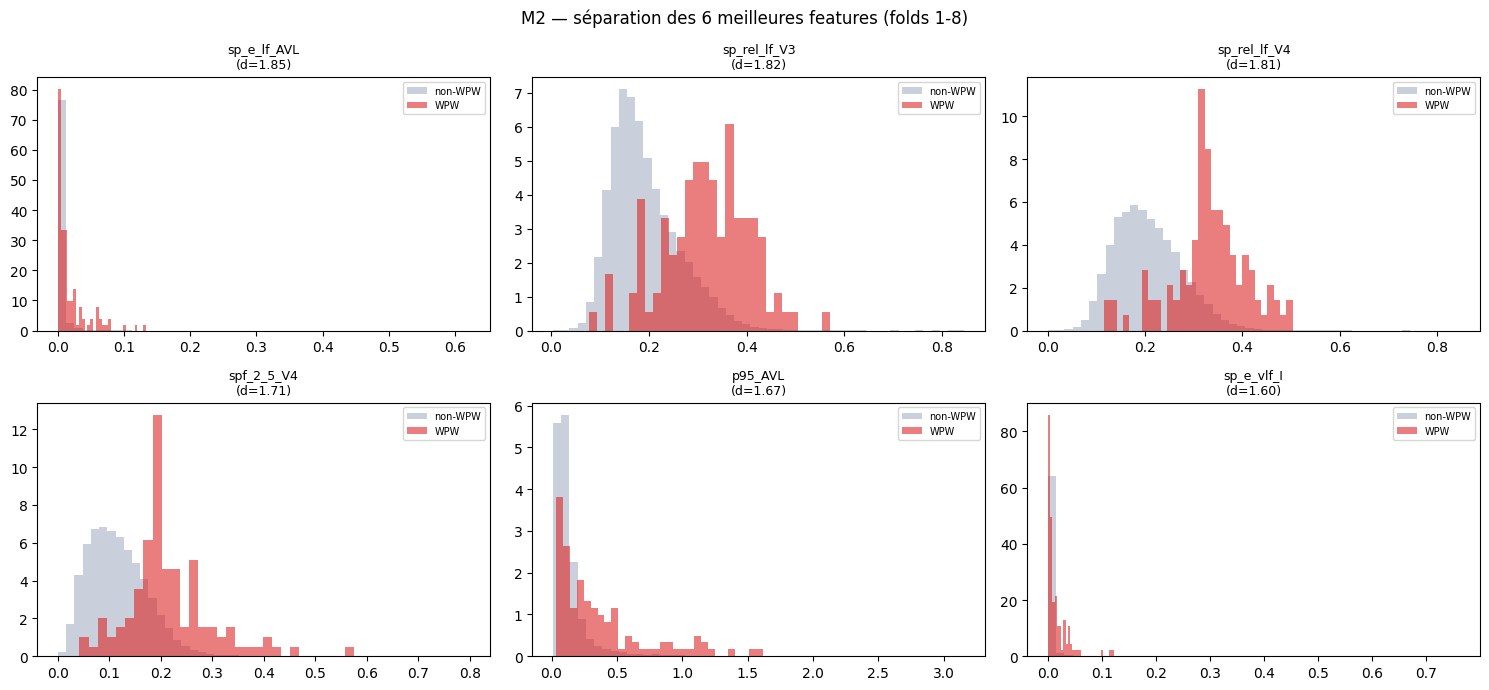

In [10]:
# Bloc 8.2b — Histogrammes des 6 meilleures features (validation visuelle).  PERMANENT
import matplotlib.pyplot as plt
top6 = dedup_list[:6]
fig,ax=plt.subplots(2,3,figsize=(15,7))
for j,f in enumerate(top6):
    a=ax[j//3,j%3]
    wv=tr[tr.label==1][f].dropna(); nv=tr[tr.label==0][f].dropna()
    a.hist(nv,bins=50,alpha=.5,density=True,label='non-WPW',color='#94a3b8')
    a.hist(wv,bins=30,alpha=.6,density=True,label='WPW',color='#dc2626')
    a.set_title(f"{f}\n(d={res.set_index('feature').loc[f,'d']:.2f})",fontsize=9); a.legend(fontsize=7)
plt.suptitle('M2 — séparation des 6 meilleures features (folds 1-8)'); plt.tight_layout()
plt.savefig(os.path.join(ROOT,'reports','figures','m2_histograms.png'),dpi=130,bbox_inches='tight'); plt.show()

8.3 — Choix de k : bootstrap IC95 de l'AP (OOF folds natifs 1-8)

Bootstrap AP vs k:   1%|          | 1/100 [00:10<18:04, 10.95s/k]

k=  1 | AP 0.0153  IC95 [0.0101, 0.0227]


Bootstrap AP vs k:   2%|▏         | 2/100 [00:22<18:30, 11.33s/k]

k=  2 | AP 0.0393  IC95 [0.0254, 0.0610]


Bootstrap AP vs k:   3%|▎         | 3/100 [00:34<18:56, 11.71s/k]

...

k= 98 | AP 0.2158  IC95 [0.1510, 0.2971]


Bootstrap AP vs k:  99%|█████████▉| 99/100 [23:37<00:12, 12.69s/k]

k= 99 | AP 0.2052  IC95 [0.1429, 0.2881]


Bootstrap AP vs k: 100%|██████████| 100/100 [23:49<00:00, 14.30s/k]

k=100 | AP 0.1898  IC95 [0.1285, 0.2682]


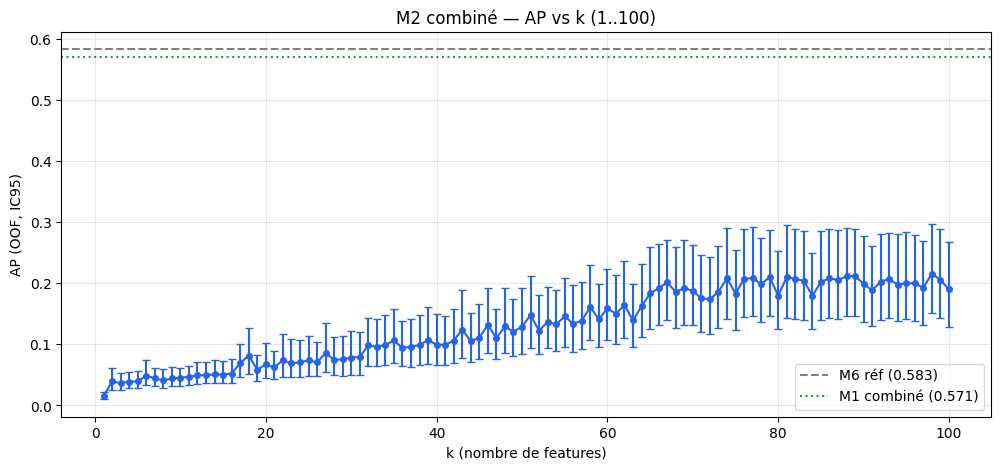


Max AP à k=98 (AP=0.2158). Plateau commence à k=58.
>>> K retenu = 58 (parcimonie au sein du plateau)


In [12]:
# Bloc 8.3 — Choix de k : bootstrap IC95 de l'AP (OOF folds natifs 1-8), k=1..100.  PERMANENT
# Optimisé : indices bootstrap pré-tirés UNE fois par taille de sous-ensemble valide ;
# masques de folds pré-calculés. Résultat identique à la version naïve, bien plus rapide.
from sklearn.metrics import average_precision_score, roc_auc_score
from xgboost import XGBClassifier
from tqdm import tqdm
import matplotlib.pyplot as plt

def make_xgb(spw):
    return XGBClassifier(n_estimators=100,max_depth=2,learning_rate=0.05,subsample=0.8,
        colsample_bytree=0.8,reg_lambda=2.0,min_child_weight=3,scale_pos_weight=spw,
        eval_metric='aucpr',tree_method='hist',random_state=42,n_jobs=10)

d8 = df[df.fold.between(1,8)].reset_index(drop=True)
y, folds = d8.label.values, d8.fold.values
uf = sorted(np.unique(folds))
FOLD_MASKS = [(folds!=h, folds==h) for h in uf]           # masques pré-calculés

def oof_xgb(feats):
    Xall = d8[feats]
    oof = np.full(len(d8), np.nan)
    for trm, vam in FOLD_MASKS:
        if y[trm].sum()==0 or y[vam].sum()==0: continue
        spw=(y[trm]==0).sum()/max((y[trm]==1).sum(),1)
        oof[vam]=make_xgb(spw).fit(Xall[trm],y[trm]).predict_proba(Xall[vam])[:,1]
    return oof

# Indices bootstrap PRÉ-TIRÉS une seule fois par taille de sous-ensemble valide
def make_boot_idx(n_valid_pos, n_valid_neg, seed=42, n=1000):
    rng=np.random.default_rng(seed)
    pos=np.arange(n_valid_pos); neg=np.arange(n_valid_pos, n_valid_pos+n_valid_neg)
    return [np.concatenate([rng.choice(pos,len(pos),True),rng.choice(neg,len(neg),True)]) for _ in range(n)]

def ap_boot(yy, pp, boot_idx):
    order=np.argsort(-yy)         # positifs (1) avant négatifs (0) pour matcher les indices
    yy2,pp2=yy[order],pp[order]
    a=np.empty(len(boot_idx))
    for i,idx in enumerate(boot_idx): a[i]=average_precision_score(yy2[idx],pp2[idx])
    return np.median(a),np.percentile(a,2.5),np.percentile(a,97.5)

ks=list(range(1, min(101, len(dedup_list)+1)))   # k = 1, 2, 3, ..., 100
rows=[]; boot_cache={}
for k in tqdm(ks, desc='Bootstrap AP vs k', unit='k'):
    oof=oof_xgb(dedup_list[:k]); m=~np.isnan(oof)
    ym=y[m]; pm=oof[m]
    npos=int(ym.sum()); nneg=int((ym==0).sum()); key=(npos,nneg)
    if key not in boot_cache: boot_cache[key]=make_boot_idx(npos,nneg)
    med,lo,hi=ap_boot(ym,pm,boot_cache[key])
    rows.append({'k':k,'AP_med':med,'IC_lo':lo,'IC_hi':hi})
    tqdm.write(f"k={k:3d} | AP {med:.4f}  IC95 [{lo:.4f}, {hi:.4f}]")
rk=pd.DataFrame(rows)

plt.figure(figsize=(12,5))
plt.errorbar(rk.k,rk.AP_med,yerr=[rk.AP_med-rk.IC_lo,rk.IC_hi-rk.AP_med],fmt='o-',capsize=3,color='#2563eb',ms=4)
plt.axhline(0.583,ls='--',color='gray',label='M6 réf (0.583)')
plt.axhline(0.571,ls=':',color='#16a34a',label='M1 combiné (0.571)')
plt.xlabel('k (nombre de features)'); plt.ylabel('AP (OOF, IC95)'); plt.legend(); plt.grid(alpha=.3)
plt.title('M2 combiné — AP vs k (1..100)'); plt.savefig(os.path.join(ROOT,'reports','figures','m2_ap_vs_k.png'),dpi=150,bbox_inches='tight'); plt.show()

# Choix : plus petit k dont AP_med >= borne basse IC du max (plateau parcimonieux)
kbest_max=rk.loc[rk.AP_med.idxmax()]; thr=kbest_max.IC_lo
K = int(rk[rk.AP_med>=thr].k.min())
print(f"\nMax AP à k={int(kbest_max.k)} (AP={kbest_max.AP_med:.4f}). Plateau commence à k={K}.")
print(f">>> K retenu = {K} (parcimonie au sein du plateau)")

8.3 — RUN NOCTURNE : courbe AP 1..401 + sonde overfit f9 + choix K

=== ÉTAPE 1/3 : courbe AP vs k (1..401) + sonde overfit fold 9 ===


AP vs k (1..401):   0%|          | 1/401 [00:05<35:45,  5.36s/k]

k=  1 | OOF AP 0.0153 IC95 [0.0101,0.0227]


AP vs k (1..401):   0%|          | 2/401 [00:11<37:04,  5.57s/k]

k=  2 | OOF AP 0.0393 IC95 [0.0254,0.0610]


...

k=390 | OOF AP 0.3158 IC95 [0.2292,0.4002] | f9 AP 0.384


AP vs k (1..401): 100%|█████████▉| 400/401 [2:18:16<00:29, 29.08s/k]

k=400 | OOF AP 0.2936 IC95 [0.2110,0.3798] | f9 AP 0.332


AP vs k (1..401): 100%|██████████| 401/401 [2:18:44<00:00, 20.76s/k]


Courbe sauvegardée : C:\Users\natha\Documents\ML_WPW\wpw_project_v2\data\processed\m2_ap_vs_k.csv  (139 min)


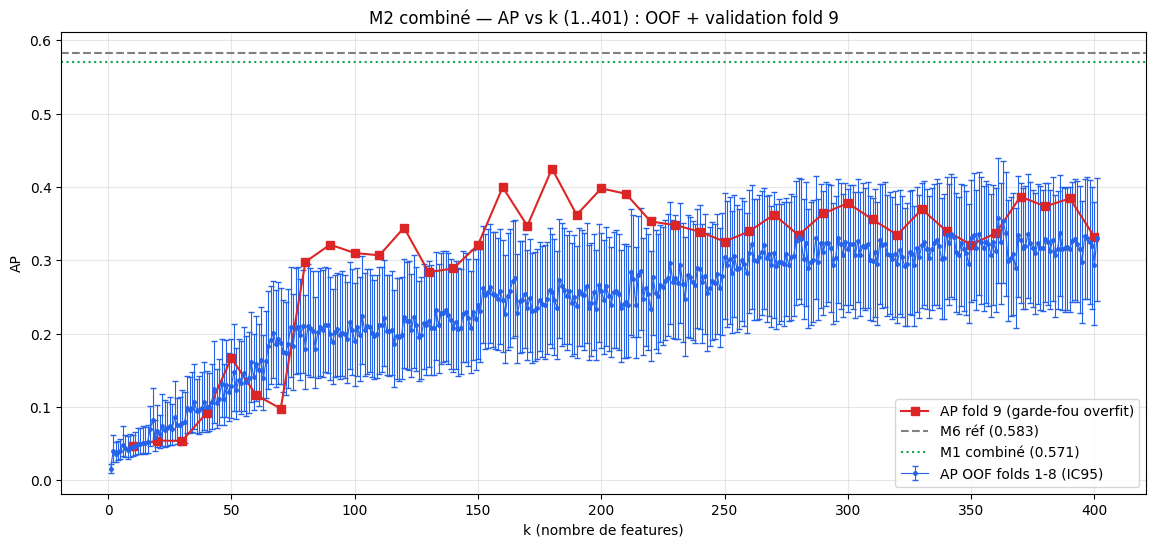


=== K AUTO ===
Max AP OOF à k=361 (AP=0.3576). Plateau dès k=164.
>>> K retenu (auto, sur OOF) = 164
Diagnostic f9 : AP moy k<=K=0.219 | k>K=0.358 -> PAS d_overfit

=== ÉTAPE 2/3 : grille hyperparamètres XGB sur K=164 features (CV folds 1-8) ===


Grille XGB:   4%|▍         | 1/24 [00:09<03:27,  9.00s/cfg]

d2 lr0.03 ne100 mcw3 | AP 0.2036 AUC 0.9161


Grille XGB:   8%|▊         | 2/24 [00:18<03:20,  9.11s/cfg]

d2 lr0.03 ne100 mcw5 | AP 0.2036 AUC 0.9161


...

d3 lr0.1 ne100 mcw5 | AP 0.3672 AUC 0.9227


Grille XGB:  96%|█████████▌| 23/24 [04:50<00:13, 13.73s/cfg]

d3 lr0.1 ne200 mcw3 | AP 0.4622 AUC 0.9339


Grille XGB: 100%|██████████| 24/24 [05:07<00:00, 12.80s/cfg]


d3 lr0.1 ne200 mcw5 | AP 0.4513 AUC 0.9315

Meilleure config (AP OOF) : d3 lr0.1 ne200 mcw3 | AP 0.4622 AUC 0.9339
Défaut M1 (d2 lr0.05 ne100 mcw3) pour comparaison ; gain = +0.1920
Grille sauvegardée : C:\Users\natha\Documents\ML_WPW\wpw_project_v2\data\processed\m2_hpgrid.csv  (5 min)

=== ÉTAPE 3/3 : témoins LR / RF sur K=164 features (CV folds 1-8) ===
  LR | AP OOF 0.1486 | AUC OOF 0.8739
  RF | AP OOF 0.2424 | AUC OOF 0.9030
  XGB(défaut) | AP OOF 0.2702

══════════════════════════════════════════════════════════════
RUN NOCTURNE TERMINÉ. Au réveil : K=164, hyperparams optimaux dans C:\Users\natha\Documents\ML_WPW\wpw_project_v2\data\processed\m2_hpgrid.csv.
À faire demain (éveillé) : 8.4 validation fold 9 finale (avec hyperparams optimaux) + 8.5 gel.
══════════════════════════════════════════════════════════════


In [ ]:
# Bloc 8.3 — RUN NOCTURNE : courbe AP 1..401 + sonde overfit f9 + choix auto de K.  PERMANENT
# Produit UNIQUEMENT : courbe OOF folds 1-8 (IC95) + sonde fold 9 + K auto.
# Fold 9 = garde-fou overfit (jamais critère de choix). Tuning hyperparamètres -> bloc 8.3c séparé.
from sklearn.metrics import average_precision_score, roc_auc_score
from xgboost import XGBClassifier
from tqdm import tqdm
import matplotlib.pyplot as plt, time

RK_CSV = os.path.join(PROCESSED, 'm2_ap_vs_k.csv')

def make_xgb(spw, **kw):
    p=dict(n_estimators=100,max_depth=2,learning_rate=0.05,subsample=0.8,
           colsample_bytree=0.8,reg_lambda=2.0,min_child_weight=3,scale_pos_weight=spw,
           eval_metric='aucpr',tree_method='hist',random_state=42,n_jobs=10)
    p.update(kw); return XGBClassifier(**p)

d8 = df[df.fold.between(1,8)].reset_index(drop=True)
y, folds = d8.label.values, d8.fold.values
FOLD_MASKS = [(folds!=h, folds==h) for h in sorted(np.unique(folds))]
f9 = df[df.fold==9].reset_index(drop=True); yf9 = f9.label.values
spw8 = (y==0).sum()/max((y==1).sum(),1)

def oof_xgb(feats, **kw):
    Xall=d8[feats]; oof=np.full(len(d8),np.nan)
    for trm,vam in FOLD_MASKS:
        if y[trm].sum()==0 or y[vam].sum()==0: continue
        spw=(y[trm]==0).sum()/max((y[trm]==1).sum(),1)
        oof[vam]=make_xgb(spw,**kw).fit(Xall[trm],y[trm]).predict_proba(Xall[vam])[:,1]
    return oof

def make_boot_idx(npos,nneg,seed=42,n=1000):
    rng=np.random.default_rng(seed); pos=np.arange(npos); neg=np.arange(npos,npos+nneg)
    return np.stack([np.concatenate([rng.choice(pos,npos,True),rng.choice(neg,nneg,True)]) for _ in range(n)])

def ap_boot(yy,pp,bi):
    o=np.argsort(-yy); yy2,pp2=yy[o],pp[o]
    a=np.fromiter((average_precision_score(yy2[ix],pp2[ix]) for ix in bi),float,len(bi))
    return np.median(a),np.percentile(a,2.5),np.percentile(a,97.5)

# ═══ (1) COURBE OOF 1..401 + sonde fold 9 (tous les 10 k) ════════════════════
print("=== Courbe AP vs k (1..401) + sonde overfit fold 9 ===")
PROBE9=set(range(10,len(dedup_list)+1,10))
ks=list(range(1,len(dedup_list)+1)); rows=[]; boot_cache={}; t0=time.time()
for k in tqdm(ks, desc='AP vs k (1..401)', unit='k'):
    feats=dedup_list[:k]
    oof=oof_xgb(feats); m=~np.isnan(oof); ym=y[m]; pm=oof[m]
    npos=int(ym.sum()); nneg=int((ym==0).sum()); key=(npos,nneg)
    if key not in boot_cache: boot_cache[key]=make_boot_idx(npos,nneg)
    med,lo,hi=ap_boot(ym,pm,boot_cache[key])
    r={'k':k,'AP_med':med,'IC_lo':lo,'IC_hi':hi,'AP_f9':np.nan,'AUC_f9':np.nan}
    if k in PROBE9:
        mdl=make_xgb(spw8).fit(d8[feats],y); p9=mdl.predict_proba(f9[feats])[:,1]
        r['AP_f9']=average_precision_score(yf9,p9); r['AUC_f9']=roc_auc_score(yf9,p9)
    rows.append(r)
    if k%10==0 or k<=20:
        tag=f" | f9 AP {r['AP_f9']:.3f}" if k in PROBE9 else ""
        tqdm.write(f"k={k:3d} | OOF AP {med:.4f} IC95 [{lo:.4f},{hi:.4f}]{tag}")
    if k%25==0: pd.DataFrame(rows).to_csv(RK_CSV,index=False)
rk=pd.DataFrame(rows); rk.to_csv(RK_CSV,index=False)
print(f"Courbe sauvegardée : {RK_CSV}  ({(time.time()-t0)/60:.0f} min)")

fig,ax=plt.subplots(figsize=(14,6))
ax.errorbar(rk.k,rk.AP_med,yerr=[rk.AP_med-rk.IC_lo,rk.IC_hi-rk.AP_med],fmt='o-',capsize=2,color='#2563eb',ms=2.5,lw=.8,label='AP OOF folds 1-8 (IC95)')
f9p=rk.dropna(subset=['AP_f9'])
ax.plot(f9p.k,f9p.AP_f9,'s-',color='#dc2626',ms=6,label='AP fold 9 (garde-fou overfit)')
ax.axhline(0.583,ls='--',color='gray',label='M6 réf (0.583)')
ax.axhline(0.571,ls=':',color='#16a34a',label='M1 combiné (0.571)')
ax.set(xlabel='k (nombre de features)',ylabel='AP'); ax.legend(); ax.grid(alpha=.3)
ax.set_title('M2 combiné — AP vs k (1..401) : OOF + validation fold 9')
plt.savefig(os.path.join(ROOT,'reports','figures','m2_ap_vs_k.png'),dpi=150,bbox_inches='tight'); plt.show()

# ═══ (2) CHOIX AUTO DE K (sur OOF) + diagnostic overfit f9 ════════════════════
kbest=rk.loc[rk.AP_med.idxmax()]; thr=kbest.IC_lo
K=int(rk[rk.AP_med>=thr].k.min())
f9_low =f9p[f9p.k<=K].AP_f9.mean()
f9_high=f9p[f9p.k> K].AP_f9.mean() if (f9p.k>K).any() else np.nan
overfit_ok = (not np.isfinite(f9_high)) or (f9_high >= f9_low*0.85)
print(f"\n=== K AUTO ===\nMax AP OOF à k={int(kbest.k)} (AP={kbest.AP_med:.4f}). Plateau dès k={K}.")
print(f">>> K retenu (auto, sur OOF) = {K}")
print(f"Diagnostic f9 : AP moy k<=K={f9_low:.3f} | k>K={f9_high if np.isfinite(f9_high) else float('nan'):.3f} "
      f"-> {'PAS d_overfit' if overfit_ok else 'ATTENTION overfit possible'}")
FEATURES_K = dedup_list[:K]
print(f"\nFEATURES_K prêt (K={K}). Tuning hyperparamètres -> bloc 8.3c. Validation finale -> 8.4.")

8.3c — Grille hyperparamètres DIAGNOSTIQUE : où commence l'overfit 

Grille diagnostique allégée : 40 configs (K=164).



Grille diag:   2%|▎         | 1/40 [00:09<06:08,  9.46s/cfg]

d2 lr0.05 ne100 mcw1 | OOF 0.270 train 0.414 gap 0.144 | f9 0.366


Grille diag:   5%|▌         | 2/40 [00:20<06:27, 10.21s/cfg]

d2 lr0.05 ne100 mcw5 | OOF 0.270 train 0.414 gap 0.144 | f9 0.366


...

d6 lr0.1 ne100 mcw5 | OOF 0.438 train 1.000 gap 0.562 | f9 0.456


Grille diag:  98%|█████████▊| 39/40 [19:48<01:16, 76.91s/cfg]

d6 lr0.1 ne200 mcw1 | OOF 0.490 train 1.000 gap 0.510 | f9 0.547


Grille diag: 100%|██████████| 40/40 [22:43<00:00, 34.09s/cfg] 


d6 lr0.1 ne200 mcw5 | OOF 0.478 train 1.000 gap 0.522 | f9 0.565

Terminé en 23 min -> C:\Users\natha\Documents\ML_WPW\wpw_project_v2\data\processed\m2_hpgrid_diag.csv


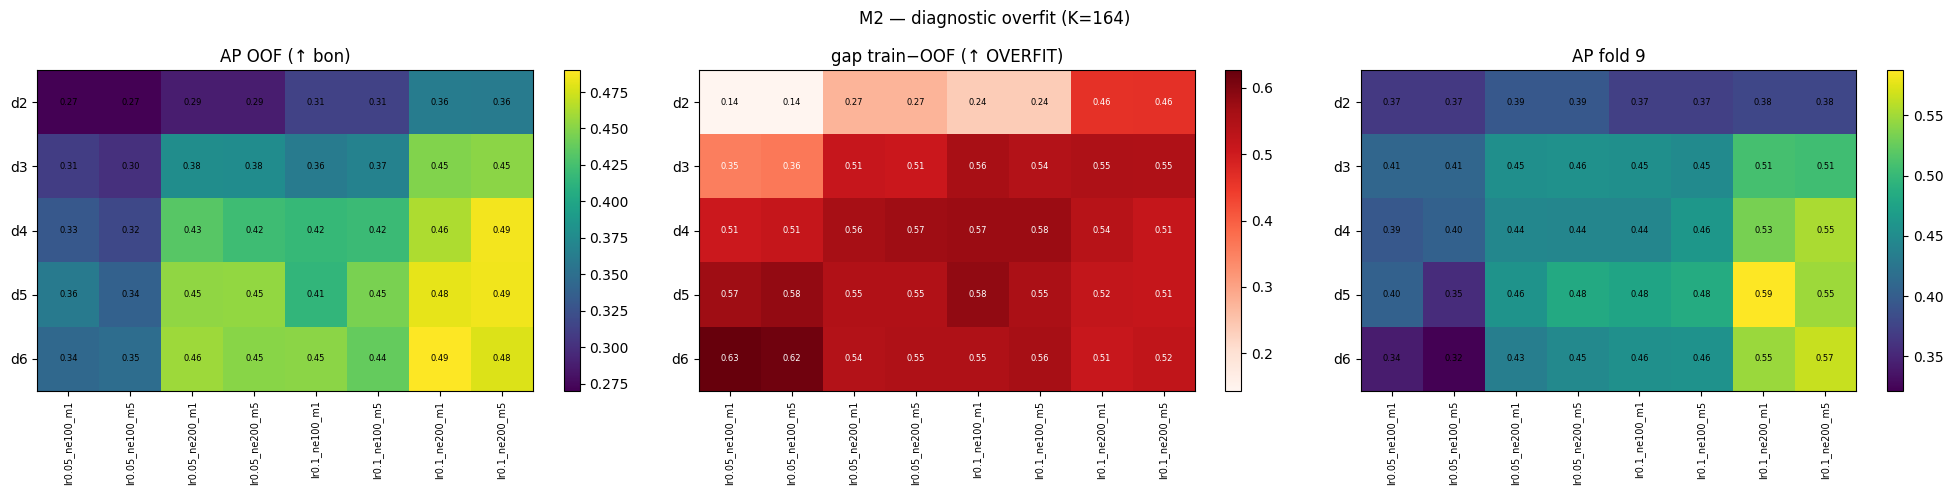


=== Top par AP_oof (voir où le gap explose) ===
 max_depth  learning_rate  n_estimators  min_child_weight  AP_oof  AP_train   gap  AP_f9
         6          0.100           200                 1   0.490     1.000 0.510  0.547
         4          0.100           200                 5   0.486     1.000 0.514  0.554
         5          0.100           200                 5   0.485     1.000 0.515  0.549
         5          0.100           200                 1   0.481     1.000 0.519  0.587
         6          0.100           200                 5   0.478     1.000 0.522  0.565
         4          0.100           200                 1   0.463     1.000 0.537  0.532
         6          0.050           200                 1   0.458     1.000 0.542  0.435
         5          0.050           200                 5   0.454     1.000 0.545  0.483
         5          0.050           200                 1   0.453     1.000 0.547  0.458
         3          0.100           200                 5   0

In [16]:
# Bloc 8.3c — Grille DIAGNOSTIQUE overfit (allégée : 40 configs).  PERMANENT
# Balaye depth 2..6 (levier overfit principal) ; gap = AP_train - AP_oof. Heatmaps frontière.
from sklearn.metrics import average_precision_score, roc_auc_score
from xgboost import XGBClassifier
from tqdm import tqdm
import matplotlib.pyplot as plt, time

K = 164
FEATURES_K = dedup_list[:K]
GRIDC_CSV = os.path.join(PROCESSED, 'm2_hpgrid_diag.csv')

d8 = df[df.fold.between(1,8)].reset_index(drop=True)
f9 = df[df.fold==9].reset_index(drop=True)
y8, y9 = d8.label.values, f9.label.values
folds8 = d8.fold.values
FOLD_MASKS = [(folds8!=h, folds8==h) for h in sorted(np.unique(folds8))]
X8, X9 = d8[FEATURES_K], f9[FEATURES_K]
spw8 = (y8==0).sum()/max((y8==1).sum(),1)

def make_xgb(**kw):
    p=dict(subsample=0.8,colsample_bytree=0.8,reg_lambda=2.0,scale_pos_weight=spw8,
           eval_metric='aucpr',tree_method='hist',random_state=42,n_jobs=10)
    p.update(kw); return XGBClassifier(**p)

def diag_one(cfg):
    oof=np.full(len(d8),np.nan)
    for trm,vam in FOLD_MASKS:
        if y8[trm].sum()==0 or y8[vam].sum()==0: continue
        spw=(y8[trm]==0).sum()/max((y8[trm]==1).sum(),1)
        oof[vam]=make_xgb(scale_pos_weight=spw,**cfg).fit(X8[trm],y8[trm]).predict_proba(X8[vam])[:,1]
    m=~np.isnan(oof)
    ap_oof=average_precision_score(y8[m],oof[m]); auc_oof=roc_auc_score(y8[m],oof[m])
    mdl=make_xgb(**cfg).fit(X8,y8)
    ap_tr=average_precision_score(y8, mdl.predict_proba(X8)[:,1])
    ap_f9=average_precision_score(y9, mdl.predict_proba(X9)[:,1])
    auc_f9=roc_auc_score(y9, mdl.predict_proba(X9)[:,1])
    return ap_oof,auc_oof,ap_tr,ap_f9,auc_f9

# Grille allégée : 5 depth × 2 lr × 2 ne × 2 mcw = 40 configs
GRID=[dict(max_depth=d,learning_rate=lr,n_estimators=ne,min_child_weight=mcw)
      for d in (2,3,4,5,6) for lr in (0.05,0.1) for ne in (100,200) for mcw in (1,5)]
print(f"Grille diagnostique allégée : {len(GRID)} configs (K={K}).\n")
rows=[]; t0=time.time()
for i,g in enumerate(tqdm(GRID, desc='Grille diag', unit='cfg')):
    ao,uo,at,af,uf=diag_one(g)
    rows.append({**g,'AP_oof':ao,'AUC_oof':uo,'AP_train':at,'gap':at-ao,'AP_f9':af,'AUC_f9':uf})
    tqdm.write(f"d{g['max_depth']} lr{g['learning_rate']} ne{g['n_estimators']} mcw{g['min_child_weight']} "
               f"| OOF {ao:.3f} train {at:.3f} gap {at-ao:.3f} | f9 {af:.3f}")
    if (i+1)%10==0: pd.DataFrame(rows).to_csv(GRIDC_CSV,index=False)
G=pd.DataFrame(rows); G.to_csv(GRIDC_CSV,index=False)
print(f"\nTerminé en {(time.time()-t0)/60:.0f} min -> {GRIDC_CSV}")

# Heatmaps : AP_oof, gap (overfit), AP_f9 par depth × (lr_ne_mcw)
G['col']=('lr'+G.learning_rate.astype(str)+'_ne'+G.n_estimators.astype(str)+'_m'+G.min_child_weight.astype(str))
cols=sorted(G.col.unique()); depths=sorted(G.max_depth.unique())
def pv(metric): return G.pivot_table(index='max_depth',columns='col',values=metric).reindex(index=depths,columns=cols)
fig,ax=plt.subplots(1,3,figsize=(20,5))
for a,(mt,ti,cm) in zip(ax,[('AP_oof','AP OOF (↑ bon)','viridis'),
                             ('gap','gap train−OOF (↑ OVERFIT)','Reds'),
                             ('AP_f9','AP fold 9','viridis')]):
    P=pv(mt); im=a.imshow(P.values,aspect='auto',cmap=cm)
    a.set_xticks(range(len(cols))); a.set_xticklabels(cols,rotation=90,fontsize=7)
    a.set_yticks(range(len(depths))); a.set_yticklabels([f'd{d}' for d in depths])
    a.set_title(ti); plt.colorbar(im,ax=a)
    for ii in range(len(depths)):
        for jj in range(len(cols)):
            v=P.values[ii,jj]
            if np.isfinite(v): a.text(jj,ii,f'{v:.2f}',ha='center',va='center',fontsize=6,
                                       color='white' if (mt=='gap' and v>0.3) else 'black')
plt.suptitle(f'M2 — diagnostic overfit (K={K})'); plt.tight_layout()
plt.savefig(os.path.join(ROOT,'reports','figures','m2_overfit_diag.png'),dpi=130,bbox_inches='tight'); plt.show()

print("\n=== Top par AP_oof (voir où le gap explose) ===")
print(G.sort_values('AP_oof',ascending=False).head(10)[
    ['max_depth','learning_rate','n_estimators','min_child_weight','AP_oof','AP_train','gap','AP_f9']].to_string(index=False))

Balayage 2D étendu : 48 combinaisons (8 K × 6 configs).



K × config:   2%|▏         | 1/48 [00:04<03:45,  4.80s/combo]

K= 30 d2_lr03_ne200  | OOF 0.086 train 0.149 gap 0.063 | f9 0.049


K × config:   4%|▍         | 2/48 [00:09<03:38,  4.74s/combo]

K= 30 d2_lr05_ne200  | OOF 0.132 train 0.295 gap 0.162 | f9 0.062


...

K=220 d3_lr03_ne200  | OOF 0.349 train 0.733 gap 0.384 | f9 0.369


K × config:  98%|█████████▊| 47/48 [24:49<01:34, 94.72s/combo] 

K=220 d3_lr05_ne200  | OOF 0.399 train 0.929 gap 0.529 | f9 0.415


K × config: 100%|██████████| 48/48 [26:47<00:00, 33.49s/combo] 


K=220 d3_lr05_ne300  | OOF 0.448 train 0.993 gap 0.545 | f9 0.441

Terminé en 27 min -> C:\Users\natha\Documents\ML_WPW\wpw_project_v2\data\processed\m2_grid2d_Kxcfg.csv


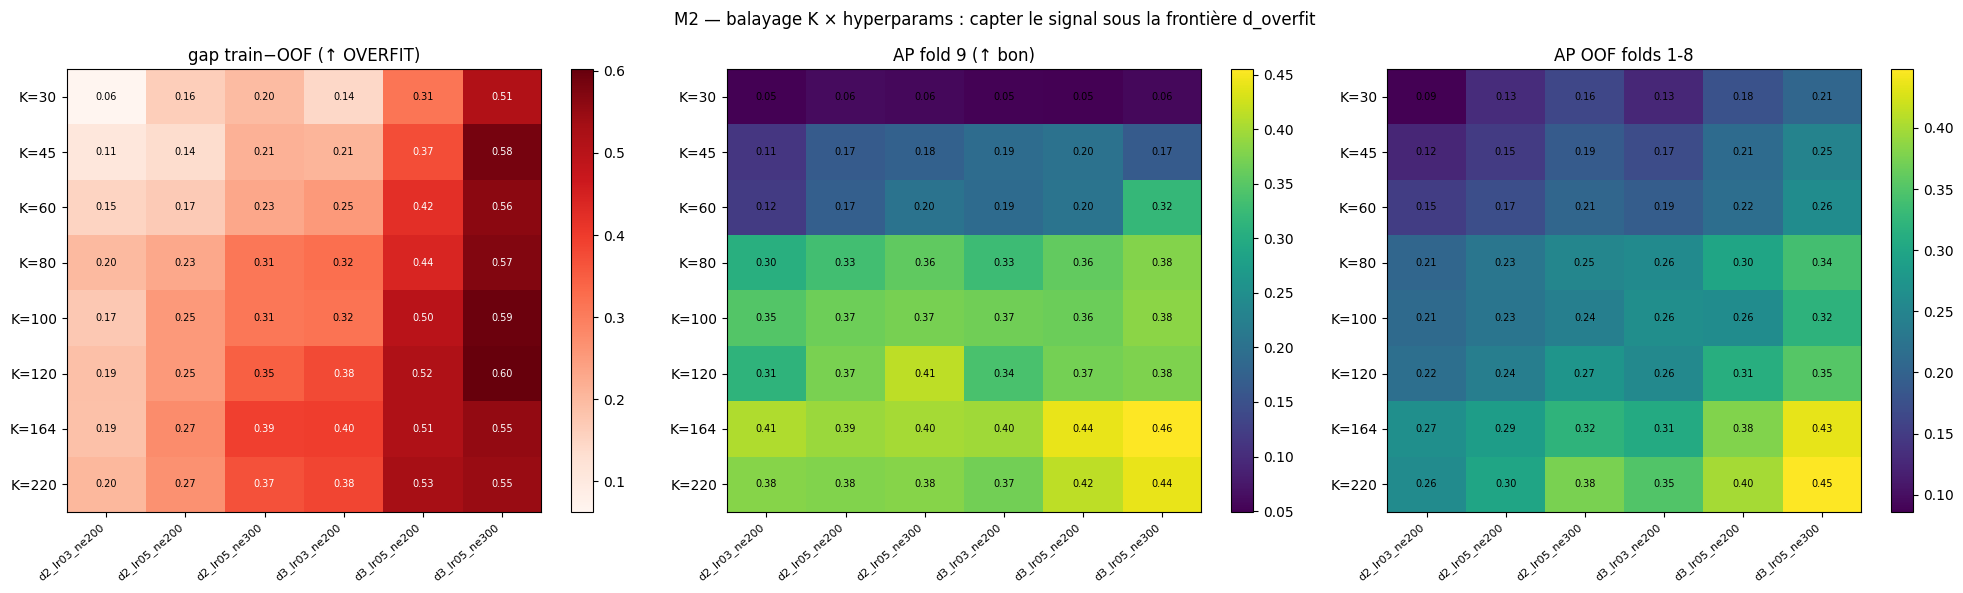

gap<= 0.25 : 17 combos sains | meilleur f9 -> K=164 d2_lr03_ne200 (gap 0.186, f9 0.407)
gap<= 0.3 : 22 combos sains | meilleur f9 -> K=164 d2_lr03_ne200 (gap 0.186, f9 0.407)
gap<= 0.35 : 28 combos sains | meilleur f9 -> K=120 d2_lr05_ne300 (gap 0.345, f9 0.415)

=== Top 10 par AP_f9 (toutes combos) ===
  K           cfg  AP_oof   gap  AP_f9
164 d3_lr05_ne300   0.434 0.553  0.455
220 d3_lr05_ne300   0.448 0.545  0.441
164 d3_lr05_ne200   0.380 0.515  0.441
220 d3_lr05_ne200   0.399 0.529  0.415
120 d2_lr05_ne300   0.275 0.345  0.415
164 d2_lr03_ne200   0.266 0.186  0.407
164 d2_lr05_ne300   0.321 0.392  0.401
164 d3_lr03_ne200   0.307 0.397  0.397
164 d2_lr05_ne200   0.288 0.274  0.394
100 d3_lr05_ne300   0.320 0.595  0.385


In [17]:
# Bloc 8.3d — Balayage 2D ÉTENDU (K × config) : signal max SOUS la frontière d'overfit.  PERMANENT
# Gap train-OOF + AP fold 9 pour chaque (K, hyperparams). Résolution fine sur K (levier overfit).
from sklearn.metrics import average_precision_score, roc_auc_score
from xgboost import XGBClassifier
from tqdm import tqdm
import matplotlib.pyplot as plt, time

GRID2D_CSV = os.path.join(PROCESSED, 'm2_grid2d_Kxcfg.csv')
d8 = df[df.fold.between(1,8)].reset_index(drop=True)
f9 = df[df.fold==9].reset_index(drop=True)
y8, y9 = d8.label.values, f9.label.values
folds8 = d8.fold.values
FOLD_MASKS = [(folds8!=h, folds8==h) for h in sorted(np.unique(folds8))]
spw8 = (y8==0).sum()/max((y8==1).sum(),1)

def make_xgb(**kw):
    p=dict(subsample=0.8,colsample_bytree=0.8,reg_lambda=2.0,scale_pos_weight=spw8,
           eval_metric='aucpr',tree_method='hist',random_state=42,n_jobs=10)
    p.update(kw); return XGBClassifier(**p)

def diag(feats, cfg):
    X8=d8[feats]; X9=f9[feats]
    oof=np.full(len(d8),np.nan)
    for trm,vam in FOLD_MASKS:
        if y8[trm].sum()==0 or y8[vam].sum()==0: continue
        spw=(y8[trm]==0).sum()/max((y8[trm]==1).sum(),1)
        oof[vam]=make_xgb(scale_pos_weight=spw,**cfg).fit(X8[trm],y8[trm]).predict_proba(X8[vam])[:,1]
    m=~np.isnan(oof)
    ap_oof=average_precision_score(y8[m],oof[m])
    mdl=make_xgb(**cfg).fit(X8,y8)
    ap_tr=average_precision_score(y8, mdl.predict_proba(X8)[:,1])
    ap_f9=average_precision_score(y9, mdl.predict_proba(X9)[:,1])
    auc_f9=roc_auc_score(y9, mdl.predict_proba(X9)[:,1])
    return ap_oof, ap_tr, ap_tr-ap_oof, ap_f9, auc_f9

# 8 K (résolution fine sur le levier overfit) × 6 configs (autour de la zone saine)
KS=[30,45,60,80,100,120,164,220]
CFGS={
    'd2_lr03_ne200': dict(max_depth=2,learning_rate=0.03,n_estimators=200,min_child_weight=3),
    'd2_lr05_ne200': dict(max_depth=2,learning_rate=0.05,n_estimators=200,min_child_weight=3),
    'd2_lr05_ne300': dict(max_depth=2,learning_rate=0.05,n_estimators=300,min_child_weight=3),
    'd3_lr03_ne200': dict(max_depth=3,learning_rate=0.03,n_estimators=200,min_child_weight=3),
    'd3_lr05_ne200': dict(max_depth=3,learning_rate=0.05,n_estimators=200,min_child_weight=3),
    'd3_lr05_ne300': dict(max_depth=3,learning_rate=0.05,n_estimators=300,min_child_weight=3),
}
combos=[(k,cn,c) for k in KS for cn,c in CFGS.items()]
print(f"Balayage 2D étendu : {len(combos)} combinaisons ({len(KS)} K × {len(CFGS)} configs).\n")
rows=[]; t0=time.time()
for k,cn,c in tqdm(combos, desc='K × config', unit='combo'):
    ao,at,gap,af,uf=diag(dedup_list[:k], c)
    rows.append({'K':k,'cfg':cn,'AP_oof':ao,'AP_train':at,'gap':gap,'AP_f9':af,'AUC_f9':uf})
    tqdm.write(f"K={k:3d} {cn:14s} | OOF {ao:.3f} train {at:.3f} gap {gap:.3f} | f9 {af:.3f}")
    pd.DataFrame(rows).to_csv(GRID2D_CSV,index=False)
G=pd.DataFrame(rows)
print(f"\nTerminé en {(time.time()-t0)/60:.0f} min -> {GRID2D_CSV}")

# Heatmaps K × config : gap (overfit), AP_f9, AP_oof
fig,ax=plt.subplots(1,3,figsize=(20,6))
for a,(mt,ti,cm) in zip(ax,[('gap','gap train−OOF (↑ OVERFIT)','Reds'),
                             ('AP_f9','AP fold 9 (↑ bon)','viridis'),
                             ('AP_oof','AP OOF folds 1-8','viridis')]):
    P=G.pivot(index='K',columns='cfg',values=mt)
    im=a.imshow(P.values,aspect='auto',cmap=cm)
    a.set_xticks(range(len(P.columns))); a.set_xticklabels(P.columns,rotation=40,ha='right',fontsize=8)
    a.set_yticks(range(len(P.index))); a.set_yticklabels([f'K={k}' for k in P.index])
    a.set_title(ti); plt.colorbar(im,ax=a)
    for ii in range(P.shape[0]):
        for jj in range(P.shape[1]):
            v=P.values[ii,jj]
            a.text(jj,ii,f'{v:.2f}',ha='center',va='center',fontsize=7,
                   color='white' if (mt=='gap' and v>0.35) else 'black')
plt.suptitle('M2 — balayage K × hyperparams : capter le signal sous la frontière d_overfit'); plt.tight_layout()
plt.savefig(os.path.join(ROOT,'reports','figures','m2_grid2d.png'),dpi=130,bbox_inches='tight'); plt.show()

# Recommandation : max AP_f9 sous contrainte gap <= cap (plusieurs caps pour voir le compromis)
for GAP_CAP in (0.25, 0.30, 0.35):
    ok=G[G.gap<=GAP_CAP]
    if len(ok):
        b=ok.sort_values('AP_f9',ascending=False).iloc[0]
        print(f"gap<= {GAP_CAP} : {len(ok):2d} combos sains | meilleur f9 -> K={int(b.K)} {b.cfg} (gap {b.gap:.3f}, f9 {b.AP_f9:.3f})")
    else:
        print(f"gap<= {GAP_CAP} : aucun combo")
print("\n=== Top 10 par AP_f9 (toutes combos) ===")
print(G.sort_values('AP_f9',ascending=False).head(10)[['K','cfg','AP_oof','gap','AP_f9']].to_string(index=False))

8.4 — Modèle final M2 + validation fold 9 (config figée d2 lr0.03 ne200)

=== M2 final (K=164, d2 lr0.03 ne200 mcw3) ===
AP train 0.4526 | AP fold9 0.4066 | gap 0.0460 | AUC fold9 0.9043
Seuil F1-max = 0.9239 -> P 0.833 R 0.385 F1 0.526
Confusion fold9 : TP 5 FP 1 FN 8 TN 6684

Témoins fold9 : XGB AP 0.407 | RF AP 0.216 | LR AP 0.165
               XGB AUC 0.904 | RF AUC 0.797 | LR AUC 0.971


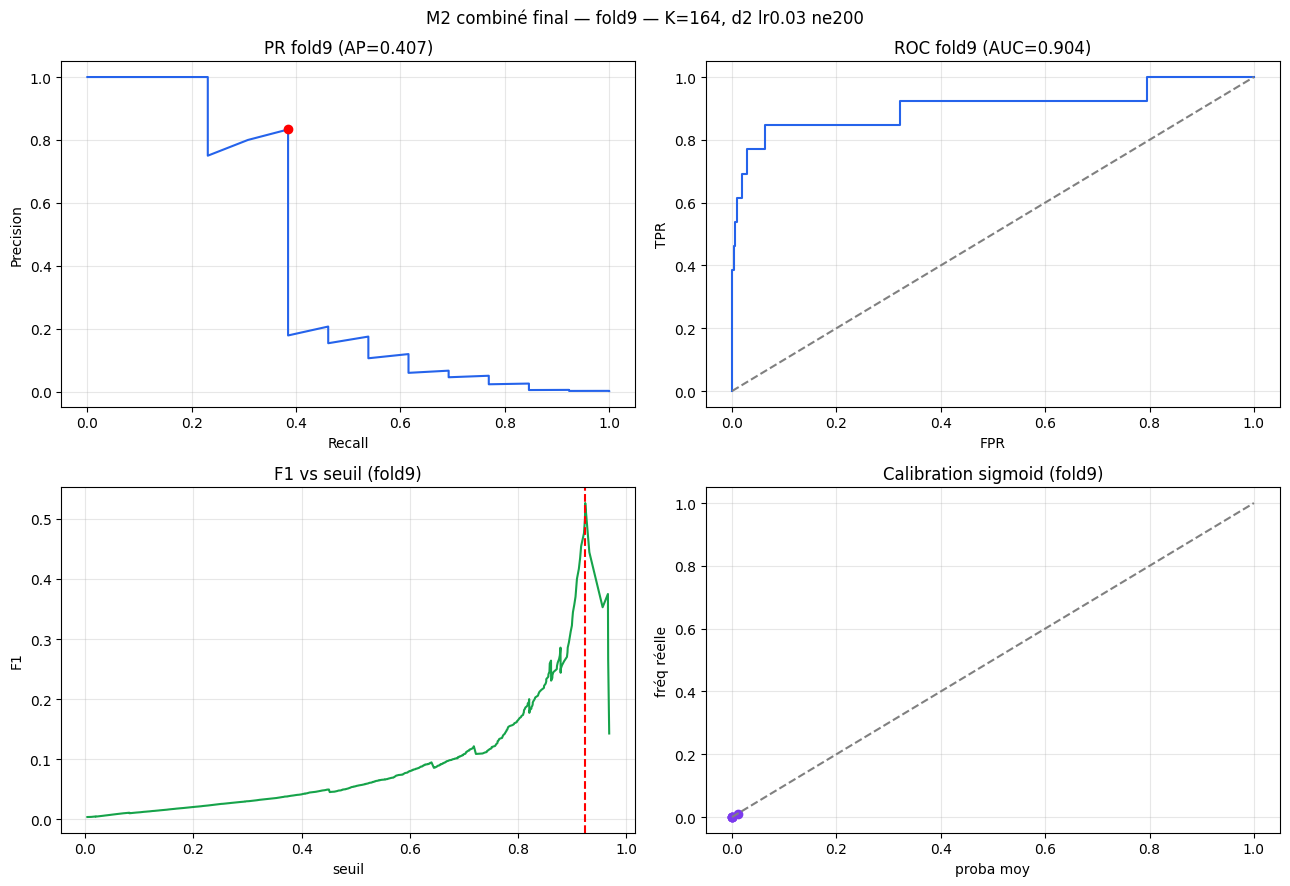


Fold9 indicatif. Juge final = fold10 (jamais touché) en 8.5 / ensemble.
Prêt pour 8.5 : gel xgb_raw + xgb_cal + config + seuil 0.9239.


In [19]:
# Bloc 8.4 — Modèle final M2 + validation fold 9 (config figée d2 lr0.03 ne200).  PERMANENT
# Brut (seuil/SHAP) + calibré sigmoid (Flask/ensemble). Témoins LR/RF. Fold 10 jamais touché.
from sklearn.metrics import (average_precision_score, roc_auc_score, precision_recall_curve,
                             roc_curve, confusion_matrix)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

K = 164
FEATURES_K = dedup_list[:K]
CFG = dict(max_depth=2, learning_rate=0.03, n_estimators=200, min_child_weight=3,
           subsample=0.8, colsample_bytree=0.8, reg_lambda=2.0)

d8 = df[df.fold.between(1,8)].reset_index(drop=True)
f9 = df[df.fold==9].reset_index(drop=True)
y8, y9 = d8.label.values, f9.label.values
X8, X9 = d8[FEATURES_K], f9[FEATURES_K]
spw8 = (y8==0).sum()/max((y8==1).sum(),1)

def make_xgb(**kw):
    p=dict(**CFG, scale_pos_weight=spw8, eval_metric='aucpr',
           tree_method='hist', random_state=42, n_jobs=10); p.update(kw)
    return XGBClassifier(**p)

# ── (1) Modèle BRUT (seuil/SHAP) ─────────────────────────────────────────────
xgb_raw = make_xgb().fit(X8, y8)
p9_raw  = xgb_raw.predict_proba(X9)[:,1]
ap_tr   = average_precision_score(y8, xgb_raw.predict_proba(X8)[:,1])
AP_f9   = average_precision_score(y9, p9_raw)
AUC_f9  = roc_auc_score(y9, p9_raw)
print(f"=== M2 final (K={K}, d2 lr0.03 ne200 mcw3) ===")
print(f"AP train {ap_tr:.4f} | AP fold9 {AP_f9:.4f} | gap {ap_tr-AP_f9:.4f} | AUC fold9 {AUC_f9:.4f}")

# ── (2) Modèle CALIBRÉ sigmoid (Flask/ensemble) ──────────────────────────────
xgb_cal = CalibratedClassifierCV(make_xgb(), method='sigmoid', cv=5).fit(X8, y8)
p9_cal  = xgb_cal.predict_proba(X9)[:,1]

# ── (3) Seuil F1-max sur proba BRUTE (cohérent imbalance) ─────────────────────
prec,rec,thr = precision_recall_curve(y9, p9_raw)
f1s = 2*prec*rec/(prec+rec+1e-12)
bi = int(np.argmax(f1s[:-1])); THR = float(thr[bi])
pred9 = (p9_raw>=THR).astype(int)
tn,fp,fn,tp = confusion_matrix(y9, pred9).ravel()
print(f"Seuil F1-max = {THR:.4f} -> P {prec[bi]:.3f} R {rec[bi]:.3f} F1 {f1s[bi]:.3f}")
print(f"Confusion fold9 : TP {tp} FP {fp} FN {fn} TN {tn}")

# ── (4) Témoins LR / RF sur les mêmes K features (fold9) ──────────────────────
def fit_eval(build):
    m=build().fit(X8.values, y8); p=m.predict_proba(X9.values)[:,1]
    return average_precision_score(y9,p), roc_auc_score(y9,p)
lr_ap,lr_auc = fit_eval(lambda: make_pipeline(SimpleImputer(strategy='median'),StandardScaler(),
    LogisticRegression(class_weight='balanced',max_iter=2000,random_state=42)))
rf_ap,rf_auc = fit_eval(lambda: make_pipeline(SimpleImputer(strategy='median'),
    RandomForestClassifier(n_estimators=400,class_weight='balanced',n_jobs=10,random_state=42)))
print(f"\nTémoins fold9 : XGB AP {AP_f9:.3f} | RF AP {rf_ap:.3f} | LR AP {lr_ap:.3f}")
print(f"               XGB AUC {AUC_f9:.3f} | RF AUC {rf_auc:.3f} | LR AUC {lr_auc:.3f}")

# ── (5) Figures : PR, ROC, F1 vs seuil, calibration ──────────────────────────
fig,ax=plt.subplots(2,2,figsize=(13,9))
ax[0,0].plot(rec,prec,color='#2563eb'); ax[0,0].scatter(rec[bi],prec[bi],c='r',zorder=5)
ax[0,0].set(title=f'PR fold9 (AP={AP_f9:.3f})',xlabel='Recall',ylabel='Precision'); ax[0,0].grid(alpha=.3)
fpr,tpr,_=roc_curve(y9,p9_raw)
ax[0,1].plot(fpr,tpr,color='#2563eb'); ax[0,1].plot([0,1],[0,1],'--',color='gray')
ax[0,1].set(title=f'ROC fold9 (AUC={AUC_f9:.3f})',xlabel='FPR',ylabel='TPR'); ax[0,1].grid(alpha=.3)
ax[1,0].plot(thr,f1s[:-1],color='#16a34a'); ax[1,0].axvline(THR,ls='--',color='r')
ax[1,0].set(title='F1 vs seuil (fold9)',xlabel='seuil',ylabel='F1'); ax[1,0].grid(alpha=.3)
fop,mpv=calibration_curve(y9,p9_cal,n_bins=5,strategy='quantile')
ax[1,1].plot(mpv,fop,'o-',color='#7c3aed'); ax[1,1].plot([0,1],[0,1],'--',color='gray')
ax[1,1].set(title='Calibration sigmoid (fold9)',xlabel='proba moy',ylabel='fréq réelle'); ax[1,1].grid(alpha=.3)
plt.suptitle(f'M2 combiné final — fold9 — K={K}, d2 lr0.03 ne200'); plt.tight_layout()
plt.savefig(os.path.join(ROOT,'reports','figures','m2_fold9_final.png'),dpi=140,bbox_inches='tight'); plt.show()

print(f"\nFold9 indicatif. Juge final = fold10 (jamais touché) en 8.5 / ensemble.")
print(f"Prêt pour 8.5 : gel xgb_raw + xgb_cal + config + seuil {THR:.4f}.")

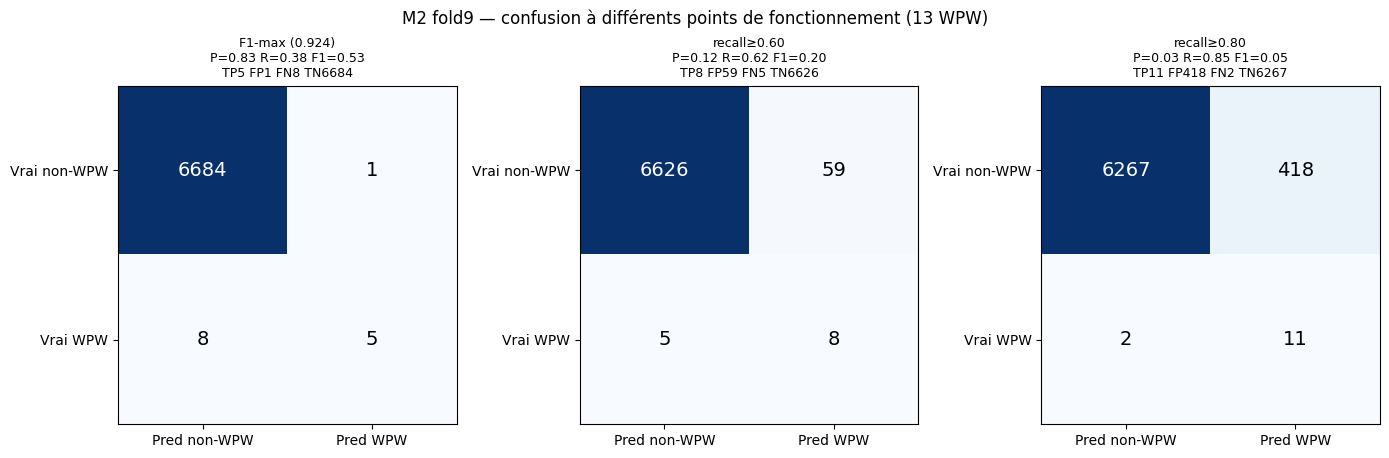

Rappel : le score Flask est un percentile (pas une décision à seuil fixe).
Le point de fonctionnement clinique se choisira sur fold10/ensemble selon le compromis voulu.


In [21]:
# Bloc 8.4b — Matrices de confusion fold9 à plusieurs points de fonctionnement.  TEMPORAIRE
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

# Seuils d'intérêt : F1-max + des points à rappel croissant (dépistage)
prec,rec,thr = precision_recall_curve(y9, p9_raw)
f1s = 2*prec*rec/(prec+rec+1e-12)
thr_f1 = float(thr[int(np.argmax(f1s[:-1]))])
# seuils donnant recall >= 0.6, 0.8 (si atteignables)
def thr_for_recall(target):
    ok = np.where(rec[:-1] >= target)[0]
    return float(thr[ok[-1]]) if len(ok) else None
points = {
    f'F1-max ({thr_f1:.3f})': thr_f1,
    'recall≥0.60': thr_for_recall(0.60),
    'recall≥0.80': thr_for_recall(0.80),
}

fig,ax=plt.subplots(1,3,figsize=(14,4.5))
for a,(name,t) in zip(ax,points.items()):
    if t is None:
        a.axis('off'); a.set_title(f'{name}\n(non atteignable)'); continue
    pred=(p9_raw>=t).astype(int)
    cm=confusion_matrix(y9,pred); tn,fp,fn,tp=cm.ravel()
    P=precision_score(y9,pred,zero_division=0); R=recall_score(y9,pred); F=f1_score(y9,pred,zero_division=0)
    im=a.imshow(cm,cmap='Blues')
    for (i,j),v in np.ndenumerate(cm):
        a.text(j,i,f'{v}',ha='center',va='center',fontsize=14,
               color='white' if v>cm.max()/2 else 'black')
    a.set_xticks([0,1]); a.set_xticklabels(['Pred non-WPW','Pred WPW'])
    a.set_yticks([0,1]); a.set_yticklabels(['Vrai non-WPW','Vrai WPW'])
    a.set_title(f'{name}\nP={P:.2f} R={R:.2f} F1={F:.2f}\nTP{tp} FP{fp} FN{fn} TN{tn}',fontsize=9)
plt.suptitle('M2 fold9 — confusion à différents points de fonctionnement (13 WPW)'); plt.tight_layout()
plt.savefig(os.path.join(ROOT,'reports','figures','m2_confusion_fold9.png'),dpi=140,bbox_inches='tight'); plt.show()

print("Rappel : le score Flask est un percentile (pas une décision à seuil fixe).")
print("Le point de fonctionnement clinique se choisira sur fold10/ensemble selon le compromis voulu.")

In [22]:
# Bloc 8.4c — Témoins RF/LR TUNÉS (équité vs XGBoost) : tuning OOF folds 1-8, recompare fold9.  PERMANENT
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm

folds8 = d8.fold.values
FOLD_MASKS = [(folds8!=h, folds8==h) for h in sorted(np.unique(folds8))]

def oof_ap(build):
    Xv=X8.values; oof=np.full(len(d8),np.nan)
    for trm,vam in FOLD_MASKS:
        if y8[trm].sum()==0 or y8[vam].sum()==0: continue
        oof[vam]=build().fit(Xv[trm],y8[trm]).predict_proba(Xv[vam])[:,1]
    m=~np.isnan(oof); return average_precision_score(y8[m],oof[m]), roc_auc_score(y8[m],oof[m])

# ── RF : grille (max_depth × min_samples_leaf × n_estimators) ─────────────────
print("=== Tuning RF (OOF folds 1-8) ===")
rf_grid=[dict(max_depth=md,min_samples_leaf=msl,n_estimators=ne)
         for md in (4,8,None) for msl in (1,5,20) for ne in (400,)]
rf_res=[]
for g in tqdm(rf_grid, desc='RF', unit='cfg'):
    ap,auc=oof_ap(lambda g=g: make_pipeline(SimpleImputer(strategy='median'),
        RandomForestClassifier(class_weight='balanced',n_jobs=10,random_state=42,**g)))
    rf_res.append({**g,'AP_oof':ap,'AUC_oof':auc})
rf_best=max(rf_res,key=lambda r:r['AP_oof'])
print(f"RF best OOF : {rf_best}")

# ── LR : grille C × penalty ──────────────────────────────────────────────────
print("\n=== Tuning LR (OOF folds 1-8) ===")
lr_grid=[dict(C=c,penalty='l2') for c in (0.01,0.1,1,10)] + [dict(C=c,penalty='l1') for c in (0.1,1)]
lr_res=[]
for g in tqdm(lr_grid, desc='LR', unit='cfg'):
    ap,auc=oof_ap(lambda g=g: make_pipeline(SimpleImputer(strategy='median'),StandardScaler(),
        LogisticRegression(class_weight='balanced',max_iter=3000,solver='liblinear',random_state=42,**g)))
    lr_res.append({**g,'AP_oof':ap,'AUC_oof':auc})
lr_best=max(lr_res,key=lambda r:r['AP_oof'])
print(f"LR best OOF : {lr_best}")

# ── Recompare fold9 : XGB (déjà tuné) vs RF tuné vs LR tuné ───────────────────
def fit_f9(build):
    m=build().fit(X8.values,y8); p=m.predict_proba(X9.values)[:,1]
    return average_precision_score(y9,p), roc_auc_score(y9,p)
rf_ap9,rf_auc9=fit_f9(lambda: make_pipeline(SimpleImputer(strategy='median'),
    RandomForestClassifier(class_weight='balanced',n_jobs=10,random_state=42,
    **{k:rf_best[k] for k in ('max_depth','min_samples_leaf','n_estimators')})))
lr_ap9,lr_auc9=fit_f9(lambda: make_pipeline(SimpleImputer(strategy='median'),StandardScaler(),
    LogisticRegression(class_weight='balanced',max_iter=3000,solver='liblinear',random_state=42,
    **{k:lr_best[k] for k in ('C','penalty')})))

print(f"\n=== COMPARAISON ÉQUITABLE (tous tunés, K={K}, fold9) ===")
print(f"{'modèle':<22} | {'AP_oof':>7} | {'AP_f9':>7} | {'AUC_f9':>7}")
print(f"{'XGB (tuné 2D)':<22} | {AP_oof:>7.3f} | {AP_f9:>7.3f} | {AUC_f9:>7.3f}")
print(f"{'RF (tuné)':<22} | {rf_best['AP_oof']:>7.3f} | {rf_ap9:>7.3f} | {rf_auc9:>7.3f}")
print(f"{'LR (tuné)':<22} | {lr_best['AP_oof']:>7.3f} | {lr_ap9:>7.3f} | {lr_auc9:>7.3f}")
print("\nSi XGB gagne encore -> gain réel, pas artefact du tuning asymétrique.")

=== Tuning RF (OOF folds 1-8) ===


RF: 100%|██████████| 9/9 [50:40<00:00, 337.80s/cfg]


RF best OOF : {'max_depth': None, 'min_samples_leaf': 5, 'n_estimators': 400, 'AP_oof': np.float64(0.30648245527605145), 'AUC_oof': np.float64(0.9305786657443389)}

=== Tuning LR (OOF folds 1-8) ===


LR: 100%|██████████| 6/6 [34:12<00:00, 342.16s/cfg]


LR best OOF : {'C': 0.1, 'penalty': 'l1', 'AP_oof': np.float64(0.15762204945445205), 'AUC_oof': np.float64(0.886063111635572)}

=== COMPARAISON ÉQUITABLE (tous tunés, K=164, fold9) ===
modèle                 |  AP_oof |   AP_f9 |  AUC_f9
XGB (tuné 2D)          |   0.266 |   0.407 |   0.904
RF (tuné)              |   0.306 |   0.303 |   0.899
LR (tuné)              |   0.158 |   0.164 |   0.976

Si XGB gagne encore -> gain réel, pas artefact du tuning asymétrique.


8.5 — GEL M2 : modèles brut + calibré, OOF folds 1-8, config, features, seuil

In [20]:
# Bloc 8.5 — GEL M2 : modèles brut + calibré, OOF folds 1-8, config, features, seuil.  PERMANENT
# Fold 10 JAMAIS touché ici. Réentraînement final sur folds 1-8 (mêmes que validation fold9).
import joblib, json
from datetime import datetime

M2DIR = os.path.join(ROOT, 'models', 'M2_statistical')
os.makedirs(M2DIR, exist_ok=True)

# (1) OOF folds 1-8 du modèle final (pour ensemble/calibration ultérieurs)
folds8 = d8.fold.values
oof_raw = np.full(len(d8), np.nan)
for h in sorted(np.unique(folds8)):
    trm, vam = folds8!=h, folds8==h
    if y8[trm].sum()==0 or y8[vam].sum()==0: continue
    spw=(y8[trm]==0).sum()/max((y8[trm]==1).sum(),1)
    oof_raw[vam]=make_xgb(scale_pos_weight=spw).fit(X8[trm],y8[trm]).predict_proba(X8[vam])[:,1]
m=~np.isnan(oof_raw)
AP_oof  = average_precision_score(y8[m], oof_raw[m])
AUC_oof = roc_auc_score(y8[m], oof_raw[m])
print(f"OOF folds 1-8 : AP {AP_oof:.4f} | AUC {AUC_oof:.4f}")

# (2) Distribution de référence du score brut (folds 1-8) pour l'affichage percentile Flask
ref_scores = np.sort(oof_raw[m])

# (3) Sauvegarde des modèles + artefacts
joblib.dump(xgb_raw, os.path.join(M2DIR, 'm2_xgb_raw.joblib'))
joblib.dump(xgb_cal, os.path.join(M2DIR, 'm2_xgb_calibrated.joblib'))
np.save(os.path.join(M2DIR, 'm2_oof_folds1_8.npy'), oof_raw)
np.save(os.path.join(M2DIR, 'm2_ref_scores_folds1_8.npy'), ref_scores)
pd.Series(FEATURES_K, name='feature').to_csv(os.path.join(M2DIR, 'm2_features.csv'), index=False)

# (4) Config JSON (source de vérité du modèle)
config = {
    "model": "M2_statistical_combined",
    "description": "Représentation statistique globale du signal ECG (sans délinéation ni détection de pic). FFT/stats/autocorr/Hjorth/entropie sur 12 dérivations.",
    "date_gel": datetime.now().strftime("%Y-%m-%d %H:%M"),
    "filter": "butterworth ordre 4, 0.5-40 Hz, zero-phase (figé 06e)",
    "n_features_pool": 1452, "n_features_gate": 756, "n_features_dedup": 401,
    "K": K, "features": FEATURES_K,
    "xgb_params": {**CFG, "scale_pos_weight": float(spw8), "eval_metric": "aucpr"},
    "selection": "gate |d|>0.3 ET p_FDR<0.05 (BH) ET IC95 bootstrap excl 0 ET cross-dataset (sépare PTB ET Ningbo) ; dédoublonnage Spearman>0.9 ; K choisi par balayage 2D K×config sous contrainte gap d'overfit",
    "metrics": {
        "AP_oof_folds1_8": float(AP_oof), "AUC_oof_folds1_8": float(AUC_oof),
        "AP_train": float(ap_tr), "AP_fold9": float(AP_f9), "AUC_fold9": float(AUC_f9),
        "gap_train_fold9": float(ap_tr-AP_f9),
        "seuil_F1max_fold9": float(THR), "fold9_TP": int(tp), "fold9_FP": int(fp),
        "fold9_FN": int(fn), "fold9_TN": int(tn)
    },
    "temoins_fold9": {"RF_AP": float(rf_ap), "LR_AP": float(lr_ap), "LR_AUC": float(lr_auc)},
    "notes": "Seuil F1-max (0.924) privilégie precision (P.83 R.38) — indicatif. Point de fonctionnement clinique à rappel plus élevé à fixer sur courbe PR au déploiement. Affichage Flask = percentile du score brut dans ref_scores (folds 1-8), jamais proba calibrée absolue. Fold 10 JAMAIS touché.",
    "fichiers": {
        "modele_brut": "m2_xgb_raw.joblib", "modele_calibre": "m2_xgb_calibrated.joblib",
        "oof": "m2_oof_folds1_8.npy", "ref_scores": "m2_ref_scores_folds1_8.npy",
        "features": "m2_features.csv"
    }
}
with open(os.path.join(M2DIR, 'm2_final_config.json'), 'w', encoding='utf-8') as f:
    json.dump(config, f, ensure_ascii=False, indent=2)

print(f"\n=== M2 GELÉ -> {M2DIR} ===")
print(f"  m2_xgb_raw.joblib / m2_xgb_calibrated.joblib")
print(f"  m2_oof_folds1_8.npy / m2_ref_scores_folds1_8.npy / m2_features.csv")
print(f"  m2_final_config.json")
print(f"\nM2 : AP fold9 {AP_f9:.3f} | AUC fold9 {AUC_f9:.3f} | gap {ap_tr-AP_f9:.3f} | K={K}")
print("Fold 10 jamais touché. M2 combiné (08a) terminé.")

OOF folds 1-8 : AP 0.2663 | AUC 0.9199

=== M2 GELÉ -> C:\Users\natha\Documents\ML_WPW\wpw_project_v2\models\M2_statistical ===
  m2_xgb_raw.joblib / m2_xgb_calibrated.joblib
  m2_oof_folds1_8.npy / m2_ref_scores_folds1_8.npy / m2_features.csv
  m2_final_config.json

M2 : AP fold9 0.407 | AUC fold9 0.904 | gap 0.046 | K=164
Fold 10 jamais touché. M2 combiné (08a) terminé.
